In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
use_cols = [
    "item_id","cat_id", "store_id", "date", "sales",
    "weekday", "event_name_1"
]

chunks = pd.read_csv(
    "../data/interim/sales_long.csv",
    usecols=use_cols,
    parse_dates=["date"],
    chunksize=500_000,      # smaller chunks
    engine="python"         # 🔥 critical fix
)


In [3]:
eda_df = []

for chunk in chunks:
    sample = chunk[chunk["store_id"].isin(["CA_1", "CA_2"])]
    sample = sample.sample(
        n=min(50_000, len(sample)), 
        random_state=42
    )
    eda_df.append(sample)

eda_df = pd.concat(eda_df, ignore_index=True)


In [4]:
eda_df.shape

(5850000, 7)

In [5]:
eda_df.head()

,item_id,cat_id,store_id,sales,date,weekday,event_name_1
0,FOODS_2_133,FOODS,CA_2,0,2011-02-05,Saturday,NaN
1,HOBBIES_1_421,HOBBIES,CA_2,0,2011-02-02,Wednesday,NaN
2,HOBBIES_1_277,HOBBIES,CA_1,2,2011-02-06,Sunday,SuperBowl
3,FOODS_3_340,FOODS,CA_2,0,2011-02-06,Sunday,SuperBowl
4,FOODS_1_148,FOODS,CA_2,0,2011-02-05,Saturday,NaN


In [6]:
eda_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850000 entries, 0 to 5849999
Data columns (total 7 columns):
 #   Column        Dtype         
---  ------        -----         
 0   item_id       object        
 1   cat_id        object        
 2   store_id      object        
 3   sales         int64         
 4   date          datetime64[ns]
 5   weekday       object        
 6   event_name_1  object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 312.4+ MB


In [7]:
eda_df["sales"].describe()


count    5.850000e+06
mean     1.145021e+00
std      3.418123e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      6.480000e+02
Name: sales, dtype: float64

Retail demand is sparse and intermittent, which makes forecasting non-trivial

In [8]:
zero_sales_ratio = (eda_df["sales"] == 0).mean()
zero_sales_ratio


np.float64(0.665283076923077)

A large proportion of zero-sales days indicates intermittent demand patterns

In [9]:
daily_sales = (eda_df.groupby("date")["sales"].sum())


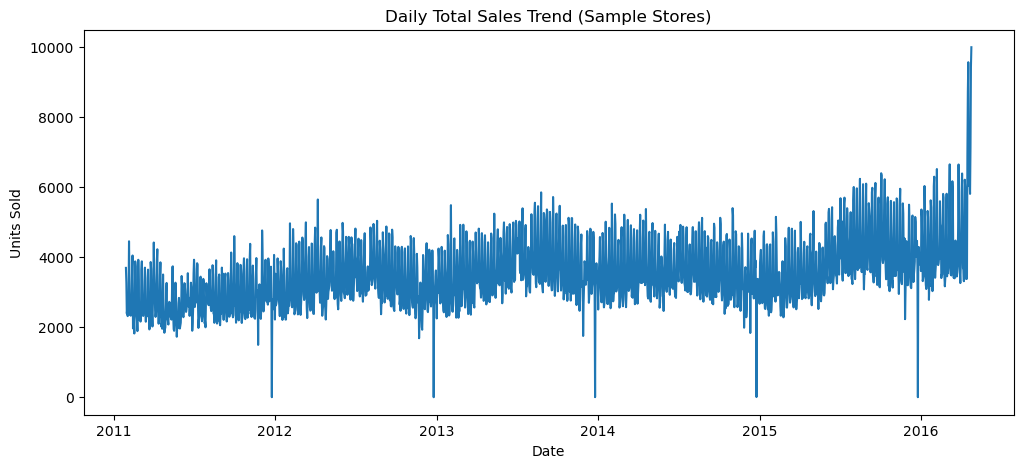

In [10]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Total Sales Trend (Sample Stores)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Sales exhibit strong temporal patterns with visible seasonal fluctuations.

In [11]:
weekday_sales = (eda_df.groupby("weekday")["sales"].mean().reindex(
        ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    ))


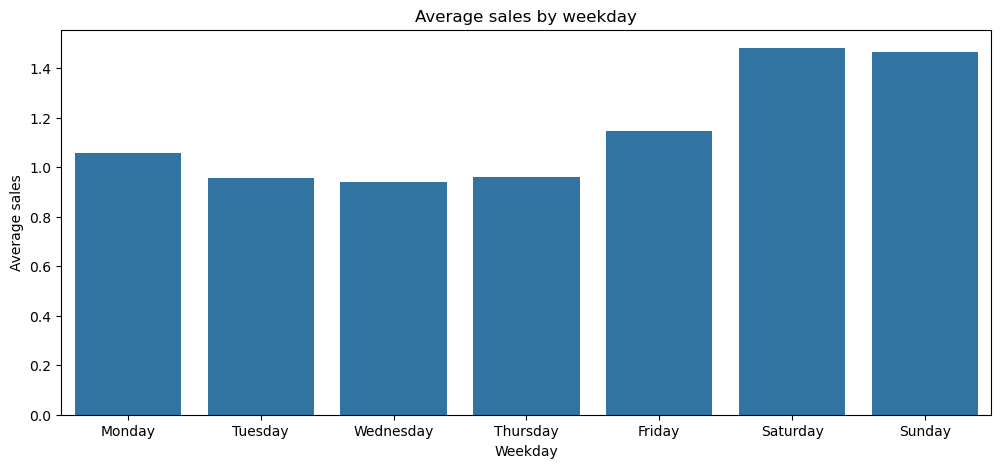

In [12]:
plt.figure(figsize=(12,5))
sns.barplot(weekday_sales)
plt.title("Average sales by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average sales")
plt.show()


In [13]:
dict_event = {True : "Event", False: "Non-Event"}

eda_df["is_event"] = eda_df["event_name_1"].notna().map(dict_event)

event_sales = eda_df.groupby("is_event")["sales"].mean()
event_sales


is_event
Event        1.078601
Non-Event    1.150809
Name: sales, dtype: float64

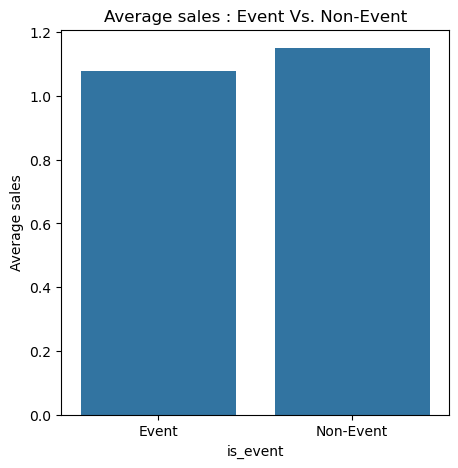

In [14]:
plt.figure(figsize=(5,5))
sns.barplot(event_sales)
plt.title("Average sales : Event Vs. Non-Event")
plt.ylabel("Average sales")
plt.show()

In [15]:
eda_df.groupby(
    ["cat_id", "is_event"]
)["sales"].mean().unstack()


is_event,Event,Non-Event
cat_id,,
FOODS,1.521854,1.615028
HOBBIES,0.631334,0.704964
HOUSEHOLD,0.709049,0.751837


In [16]:
store_sales = (eda_df.groupby("store_id")["sales"].mean())


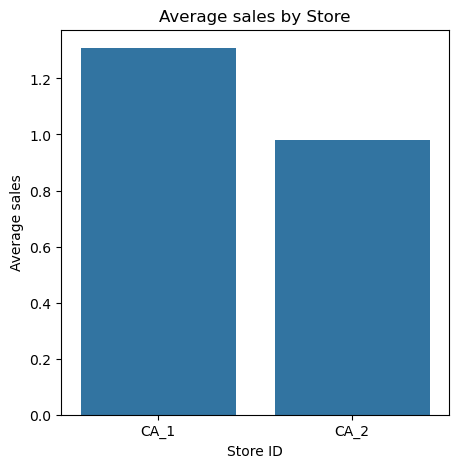

In [17]:
plt.figure(figsize=(5,5))
sns.barplot(store_sales)
plt.title("Average sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Average sales")
plt.show()

# Exploratory Data Analysis (EDA) - Insights

This EDA was performed on a sampled subset of the M5 dataset using
chunk-based loading due to the large scale of the data.
The analysis focuses on understanding demand distribution, sparsity,
temporal patterns, event effects, category behavior, and store-level differences.

---

## Sales Distribution & Sparsity

Summary statistics of daily sales per item-store-day:

- Mean sales: **~1.15 units**
- Median (50%): **0 units**
- 75th percentile: **1 unit**
- Maximum observed sales: **648 units**

The median being zero indicates that **most item–store combinations do not sell every day**.

### Zero-Sales Ratio

- **66.5% of observations have zero sales**

This confirms that the dataset exhibits **highly intermittent demand**, which is a
common and realistic challenge in retail forecasting.

**Implication:**  
Models must handle sparse demand effectively and should rely on temporal patterns
rather than assuming continuous sales.

---

## Temporal Sales Patterns

### Daily Sales Trend

The aggregated daily sales trend for sample stores shows:

- Clear **long-term temporal structure**
- Repeating seasonal fluctuations
- Occasional sharp drops and spikes, likely due to holidays or calendar effects

Sales are **non-stationary**, reinforcing the need for lag-based and rolling features.

---

## Weekly Seasonality

Average sales by weekday reveal a strong weekly pattern:

- Sales are **lowest during mid-week**
- Sales increase toward the weekend
- **Saturday and Sunday have the highest average sales**

This reflects typical consumer shopping behavior.

**Implication:**  
Day-of-week effects are significant and should be explicitly modeled.

---

## Event vs Non-Event Analysis (Overall)

Average sales comparison shows:

- **Non-event days have higher average sales than event days**

This indicates that calendar events do **not** act like promotions.
Instead, events influence consumer behavior unevenly across products.

**Key Insight:**  
Event impact is not uniform and should not be assumed to increase overall demand.

---

## Category-wise Event Impact

Category-level comparison of average sales:

| Category   | Event Avg Sales | Non-Event Avg Sales |
|-----------|----------------|---------------------|
| FOODS     | 1.52           | 1.62                |
| HOBBIES   | 0.63           | 0.70                |
| HOUSEHOLD | 0.71           | 0.75                |

Across all major categories:
- Average sales are **lower on event days**
- Event effects are **heterogeneous and category-specific**

**Interpretation:**  
Events redistribute demand rather than universally increasing it.
Some items benefit from events, while many others experience reduced or zero sales.

---

## Store-Level Behavior

Average sales by store show clear differences:

- **CA_1 has higher average sales than CA_2**

This indicates the presence of **location-specific demand patterns**.

**Implication:**  
Store-level effects are important and must be incorporated into the model.

---

## Key EDA Insights

- Retail demand is **sparse and intermittent**, with a majority of zero-sales days
- Strong **weekly seasonality** is present
- Sales patterns evolve over time and are non-stationary
- Event effects are **non-linear and not globally positive**
- Demand varies significantly across stores and categories

---

## Modeling Implications

Based on the EDA findings:

- Lag features (7, 14, 28 days) are essential
- Rolling statistics help smooth intermittent demand
- Day-of-week and calendar features should be included
- Event indicators should be used, allowing the model to learn their relevance
- Store-level identifiers are critical
- Tree-based models (e.g., LightGBM) are well-suited for this data

---

## Conclusion

The EDA confirms that the M5 dataset represents a realistic and challenging
retail forecasting problem. The observed sparsity, seasonality, and heterogeneous
event effects strongly justify a feature-rich, non-linear modeling approach.
